In [1]:
!pip install mglearn
!pip install tenserflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 12.1 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement tenserflow (from versions: none)
ERROR: No matching distribution found for tenserflow


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [6]:
np.random.seed(180)
tf.random.set_seed(180)

In [7]:
people = fetch_lfw_people(min_faces_per_person=20,resize=0.7)
print(people.data.shape)
print(people.target.shape)
image_shape = people.images[0].shape

(3023, 5655)
(3023,)


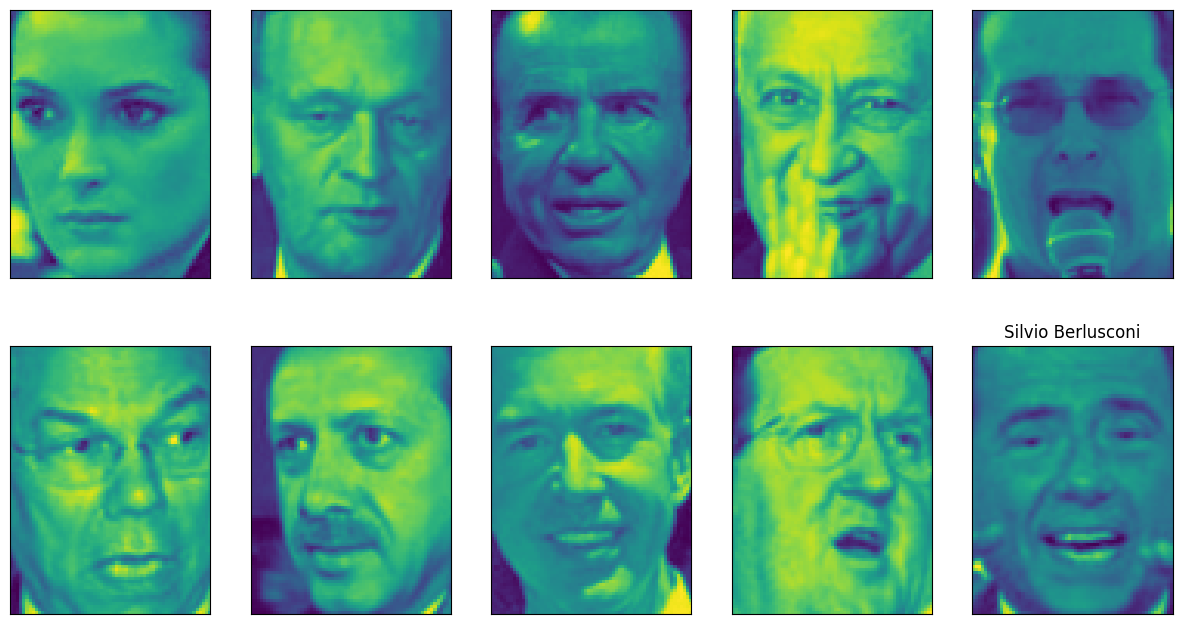

In [10]:
fix, axes = plt.subplots(2,5,figsize=(15,8),subplot_kw={'xticks':(), 'yticks':()})
for target, image, ax in zip(people.target,people.images,axes.ravel()):
  ax.imshow(image)
ax.set_title(people.target_names[target])
plt.show()


In [11]:
X_train, X_test, y_train, y_test = train_test_split(people.data,people.target, test_size=0.2, random_state=20)
y_train = y_train.astype(int)
y_test = y_test.astype(int)
batch_size = len(X_train)
print(X_train.shape,y_train.shape,y_test.shape)
print("people.images.shape: {}".format(people.images.shape))
print("Number of classes: {}".format(len(people.target_names)))


(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [12]:
count = np.bincount(people.target)
for i, (count, name) in enumerate(zip(count, people.target_names)):
  print( "{0:25} {1:3}".format(name,count),end=" ")
if (i+1)%3 == 0:
  print()


Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 Carlos Menem               21 Colin Powell              236 David Beckham              31 Donald Rumsfeld           121 George Robertson           22 George W Bush             530 Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 Jose Maria

In [13]:
mask = np.zeros(people.target.shape,dtype=np.bool_)
for target in np.unique(people.target):
    mask[np.where(people.target == target)[0][:50]] = True
    X_people = people.data[mask]
    y_people = people.target[mask]
X_people = X_people / 255.0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_people,y_people,stratify=y_people,random_state=0)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit( X_train, y_train)
print( "Test set score of 1-nn: {:.2f}".format(knn.score(X_test,y_test)))


Test set score of 1-nn: 0.22


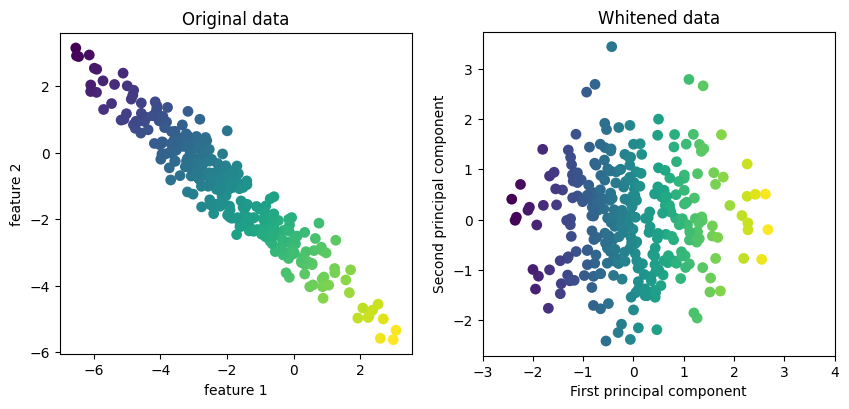

In [16]:
mglearn.plots.plot_pca_whitening()
plt.show()


In [18]:
pca = PCA(n_components=100,whiten=True,random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("X_train_pca.shape: {}".format(X_train_pca.shape))
# KNN with PCA
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca,y_train)
print("Test set accuracy: {:.2f}".format(knn.score(X_test_pca,y_test)))
print("pca.components_.shape: {}".format(pca.components_.shape))


X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


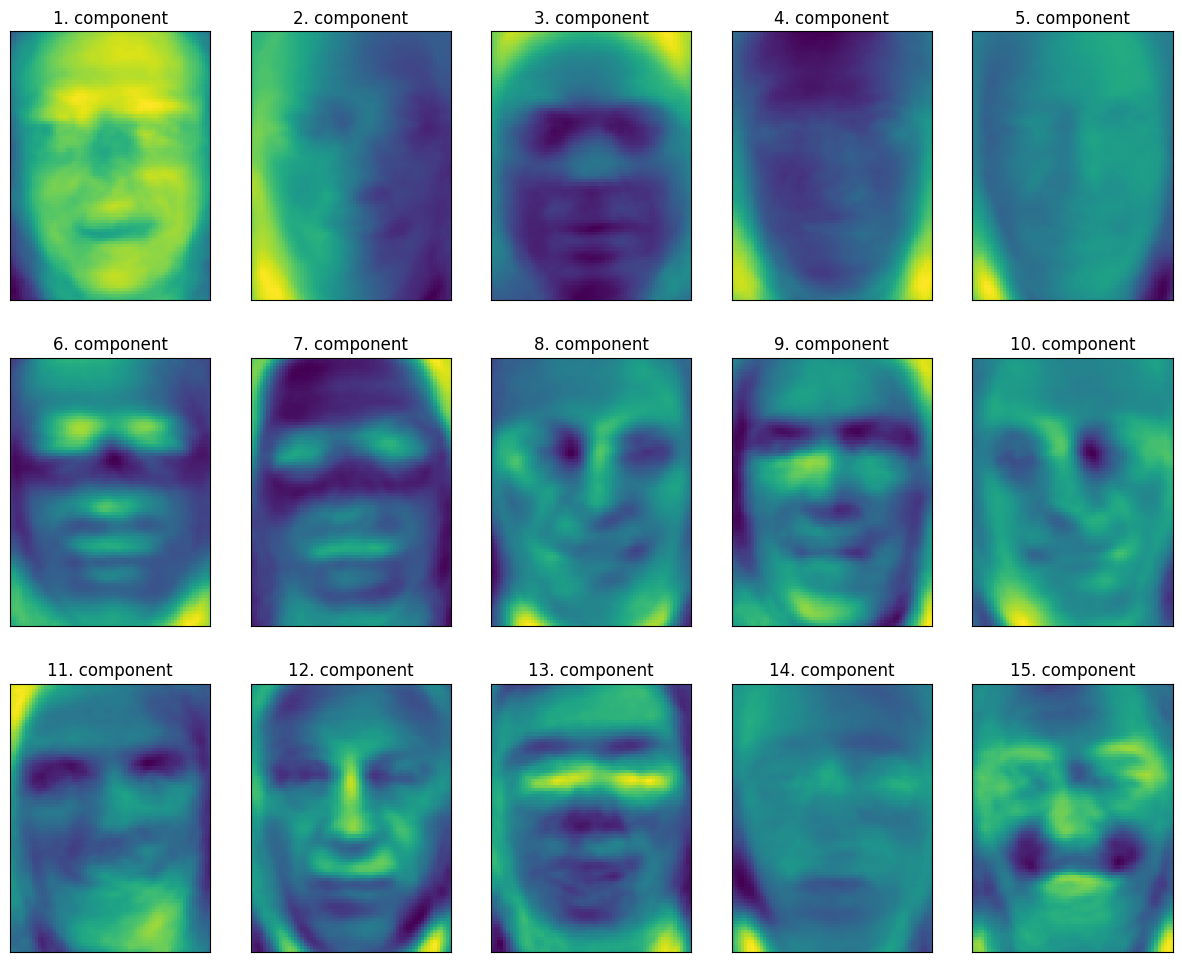

In [22]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 12),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for i, (component, ax) in enumerate(
    zip(pca.components_, axes.ravel())
):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title("{}. component".format(i + 1))

plt.show()


In [23]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform( X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)


In [25]:
model = Sequential([Input(shape=(100,)),Dense(300,activation='relu'),Dense(100,activation='relu'),Dense( len(np.unique(y_train)),activation='softmax')])

In [26]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']
)


In [27]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0213 - loss: 4.1220
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0284 - loss: 4.0830
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0317 - loss: 4.0628
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0388 - loss: 4.0371
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0556 - loss: 4.0158
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0769 - loss: 3.9857
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0911 - loss: 3.9508
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1054 - loss: 3.9066
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1357 - loss: 3.8496
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1545 - loss: 3.7823
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1597 - loss: 3.6990
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.184

In [28]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2713 - loss: 2.9716
Test Loss: 2.971632719039917
Test Accuracy: 0.27131783962249756
